<a href="https://www.kaggle.com/code/hrishikeshthakur7/higgsbosonusingoptuna?scriptVersionId=305381955" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Imports


In [1]:
import pandas as pd
import numpy as np
import optuna
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/knight079/higgsb/training.csv")

# Remove leakage columns
df.drop(['EventId', 'Weight'], axis=1, inplace=True)

# Handle missing values
df.replace(-999, np.nan, inplace=True)


# Encode labels
df['Label'] = df['Label'].map({'s': 1, 'b': 0})

X = df.drop('Label', axis=1)
y = df['Label']

In [3]:
df.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,1
1,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226,0
2,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251,0
3,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,75.968,...,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,0
4,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,57.983,...,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0


In [4]:
df.fillna(df.median(), inplace=True)

# Train/Validation Split

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Scaling

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## Optuna 

In [7]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
    }

    model = XGBClassifier(**params, eval_metric="logloss")

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, preds)

In [8]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Params:", study.best_params)
print("Best Validation AUC:", study.best_value)

[I 2026-03-21 13:53:20,980] A new study created in memory with name: no-name-17eba65c-444c-4353-a364-51f4e446f6d9
[I 2026-03-21 13:53:25,284] Trial 0 finished with value: 0.909549722029387 and parameters: {'n_estimators': 477, 'max_depth': 3, 'learning_rate': 0.07841237109131692, 'subsample': 0.6708169235129127, 'colsample_bytree': 0.6509416511202547, 'gamma': 3.5194587089360563, 'reg_lambda': 1.4262575472708117}. Best is trial 0 with value: 0.909549722029387.
[I 2026-03-21 13:53:35,623] Trial 1 finished with value: 0.9106668932917069 and parameters: {'n_estimators': 305, 'max_depth': 9, 'learning_rate': 0.11089640625821577, 'subsample': 0.8570054618306667, 'colsample_bytree': 0.9625863665074373, 'gamma': 1.3594146983624023, 'reg_lambda': 1.7996970910592358}. Best is trial 1 with value: 0.9106668932917069.
[I 2026-03-21 13:53:42,026] Trial 2 finished with value: 0.91248526189412 and parameters: {'n_estimators': 491, 'max_depth': 5, 'learning_rate': 0.0923813426387432, 'subsample': 0.61

Best Params: {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.0770083415881378, 'subsample': 0.793470373901705, 'colsample_bytree': 0.838376037910771, 'gamma': 1.1036643548737013, 'reg_lambda': 4.024422792123744}
Best Validation AUC: 0.9125885289780251


In [9]:
best_model = XGBClassifier(**study.best_params, eval_metric="logloss")
best_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.838376037910771, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=1.1036643548737013, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0770083415881378,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=409, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluation

In [10]:
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:,1])
val_auc = roc_auc_score(y_val, best_model.predict_proba(X_val)[:,1])

print("Train AUC:", train_auc)
print("Validation AUC:", val_auc)

Train AUC: 0.9248934451301123
Validation AUC: 0.9125885289780251


## ROC Curve

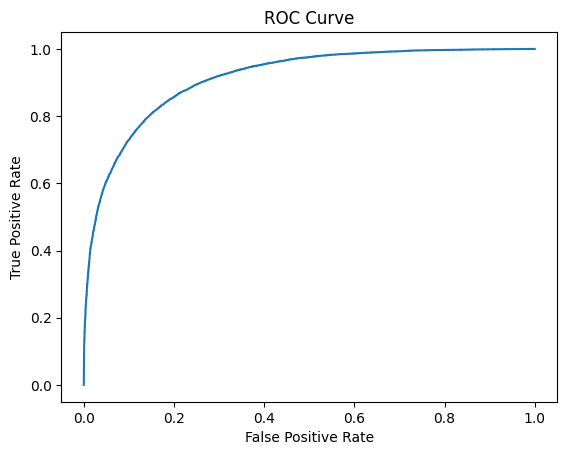

In [11]:
probs = best_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Save Model

In [12]:
joblib.dump(best_model, "higgs_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Use Test Set

In [13]:
test_df = pd.read_csv("/kaggle/input/datasets/knight079/higgsb/test.csv")

event_ids = test_df["EventId"]

# Same preprocessing
test_df.drop(['EventId'], axis=1, inplace=True)
test_df.replace(-999, np.nan, inplace=True)
test_df.fillna(test_df.median(), inplace=True)

test_scaled = scaler.transform(test_df)

predictions = best_model.predict_proba(test_scaled)[:, 1]

## Save Submission

In [14]:
submission = pd.DataFrame({
    "EventId": event_ids,
    "Prediction": predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved!")

Submission file saved!
